# Bomberman Evaluation Plots

This notebook stores evaluation results as `results[model_name][test_run][metric]` and creates report-ready comparison plots.

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
OUTPUT_DIR = Path('plots')
OUTPUT_DIR.mkdir(exist_ok=True)

In [ ]:
# Data structure: results[model_name][test_run][metric] = value
# Missing metrics are deliberately omitted rather than represented as zero.
results = {
    'qtable-mode1': {
        'coin_solo': {'coins': 47.7, 'coin_total': 50, 'collect_rate': 0.95, 'coins/step': 0.220, 'steps_alive': 217, 'stuck_rate': 0.33, 'suicides/round': 0.00, 'invalid_rate': 0.000},
        'coin_vs_collectors': {'coin_share': 0.23, 'coins': 11.7, 'win_rate': 0.14, 'stuck_rate': 1.00, 'survival_rate': 1.00},
    },
    'dqn-mode1-initial': {
        'move_solo_coinheaven': {'survival_rate': 1.00, 'suicides/round': 0.00, 'stuck_rate': 1.00, 'action_loop_rate': 0.913, 'pos_loop_rate': 0.913, 'invalid_rate': 0.000, 'wait_rate': 0.003, 'tile_diversity': 0.07, 'coins': 15.4},
        'move_vs_peaceful': {'survival_rate': 0.23, 'suicides/round': 0.77, 'stuck_rate': 0.23, 'action_loop_rate': 0.182, 'pos_loop_rate': 0.182, 'invalid_rate': 0.019, 'wait_rate': 0.333, 'tile_diversity': 0.24, 'coins': 1.0},
        'coin_solo': {'coins': 15.4, 'coin_total': 50, 'collect_rate': 0.31, 'coins/step': 0.039, 'steps_alive': 400, 'stuck_rate': 1.00, 'suicides/round': 0.00, 'invalid_rate': 0.000},
        'coin_vs_collectors': {'coin_share': 0.17, 'coins': 8.6, 'win_rate': 0.01, 'stuck_rate': 0.99, 'survival_rate': 0.98},
        'combat_3rule': {'win_rate': 0.00, 'mean_rank': 3.56, 'score': 0.65, 'kills/round': 0.01, 'suicides/round': 0.83, 'survival_rate': 0.01, 'steps_survived': 49, 'stuck_rate': 0.13, 'coin_share': 0.07},
        'combat_mixed': {'win_rate': 0.02, 'mean_rank': 2.68, 'score': 0.97, 'kills/round': 0.02, 'suicides/round': 0.82, 'survival_rate': 0.04, 'steps_survived': 69, 'stuck_rate': 0.20, 'coin_share': 0.10},
        'combat_vs_oldmodel': {'win_rate': 0.01, 'mean_rank': 2.80, 'score': 0.74, 'kills/round': 0.01, 'suicides/round': 0.85, 'survival_rate': 0.01, 'steps_survived': 55, 'stuck_rate': 0.12, 'coin_share': 0.08},
    },
    'dqn-mode2-initial': {
        'move_solo_coinheaven': {'survival_rate': 0.97, 'suicides/round': 0.03, 'stuck_rate': 0.97, 'action_loop_rate': 0.758, 'pos_loop_rate': 0.754, 'invalid_rate': 0.006, 'wait_rate': 0.206, 'tile_diversity': 0.16, 'coins': 25.1},
        'move_vs_peaceful': {'survival_rate': 0.07, 'suicides/round': 0.93, 'stuck_rate': 0.06, 'action_loop_rate': 0.024, 'pos_loop_rate': 0.023, 'invalid_rate': 0.010, 'wait_rate': 0.291, 'tile_diversity': 0.31, 'coins': 1.4},
        'coin_solo': {'coins': 25.1, 'coin_total': 50, 'collect_rate': 0.50, 'coins/step': 0.064, 'steps_alive': 390, 'stuck_rate': 0.97, 'suicides/round': 0.03, 'invalid_rate': 0.006},
        'coin_vs_collectors': {'coin_share': 0.17, 'coins': 8.8, 'win_rate': 0.05, 'stuck_rate': 0.83, 'survival_rate': 0.83},
        'combat_3rule': {'win_rate': 0.04, 'mean_rank': 3.24, 'score': 1.00, 'kills/round': 0.04, 'suicides/round': 0.83, 'survival_rate': 0.01, 'steps_survived': 63, 'stuck_rate': 0.05, 'coin_share': 0.09},
        'combat_mixed': {'win_rate': 0.05, 'mean_rank': 2.56, 'score': 1.49, 'kills/round': 0.06, 'suicides/round': 0.85, 'survival_rate': 0.04, 'steps_survived': 74, 'stuck_rate': 0.05, 'coin_share': 0.13},
        'combat_vs_oldmodel': {'win_rate': 0.07, 'mean_rank': 2.62, 'score': 1.53, 'kills/round': 0.11, 'suicides/round': 0.84, 'survival_rate': 0.02, 'steps_survived': 69, 'stuck_rate': 0.03, 'coin_share': 0.11},
    },
    'dqn-mode1-anticycles': {
        'move_solo_coinheaven': {'survival_rate': 1.00, 'suicides/round': 0.00, 'stuck_rate': 0.58, 'action_loop_rate': 0.376, 'pos_loop_rate': 0.357, 'invalid_rate': 0.000, 'wait_rate': 0.041, 'tile_diversity': 0.52, 'coins': 44.8},
        'move_vs_peaceful': {'survival_rate': 0.57, 'suicides/round': 0.43, 'stuck_rate': 0.57, 'action_loop_rate': 0.566, 'pos_loop_rate': 0.565, 'invalid_rate': 0.000, 'wait_rate': 0.485, 'tile_diversity': 0.16, 'coins': 0.1},
        'coin_solo': {'coins': 44.8, 'coin_total': 50, 'collect_rate': 0.90, 'coins/step': 0.167, 'steps_alive': 267, 'stuck_rate': 0.58, 'suicides/round': 0.00, 'invalid_rate': 0.000},
        'coin_vs_collectors': {'coin_share': 0.22, 'coins': 11.2, 'win_rate': 0.09, 'stuck_rate': 0.88, 'survival_rate': 0.83},
        'combat_3rule': {'win_rate': 0.00, 'mean_rank': 3.76, 'score': 0.11, 'kills/round': 0.00, 'suicides/round': 0.78, 'survival_rate': 0.00, 'steps_survived': 66, 'stuck_rate': 0.54, 'coin_share': 0.01},
        'combat_mixed': {'win_rate': 0.00, 'mean_rank': 2.85, 'score': 0.26, 'kills/round': 0.03, 'suicides/round': 0.75, 'survival_rate': 0.04, 'steps_survived': 92, 'stuck_rate': 0.55, 'coin_share': 0.01},
        'combat_vs_oldmodel': {'win_rate': 0.01, 'mean_rank': 2.92, 'score': 0.20, 'kills/round': 0.00, 'suicides/round': 0.75, 'survival_rate': 0.00, 'steps_survived': 86, 'stuck_rate': 0.56, 'coin_share': 0.02},
    },
    'dqn-mode2-selfkill': {
        'move_solo_coinheaven': {'survival_rate': 1.00, 'suicides/round': 0.00, 'stuck_rate': 0.02, 'action_loop_rate': 0.015, 'pos_loop_rate': 0.015, 'invalid_rate': 0.000, 'wait_rate': 0.000, 'tile_diversity': 0.82, 'coins': 49.9},
        'move_vs_peaceful': {'survival_rate': 0.09, 'suicides/round': 0.91, 'stuck_rate': 0.08, 'action_loop_rate': 0.036, 'pos_loop_rate': 0.036, 'invalid_rate': 0.000, 'wait_rate': 0.202, 'tile_diversity': 0.28, 'coins': 2.4},
        'coin_solo': {'coins': 49.9, 'coin_total': 50, 'collect_rate': 1.00, 'coins/step': 0.381, 'steps_alive': 131, 'stuck_rate': 0.02, 'suicides/round': 0.00, 'invalid_rate': 0.000},
        'coin_vs_collectors': {'coin_share': 0.24, 'coins': 12.2, 'win_rate': 0.19, 'stuck_rate': 1.00, 'survival_rate': 1.00},
        'combat_3rule': {'win_rate': 0.06, 'mean_rank': 2.84, 'score': 1.83, 'kills/round': 0.05, 'suicides/round': 0.62, 'survival_rate': 0.04, 'steps_survived': 79, 'stuck_rate': 0.03, 'coin_share': 0.18},
        'combat_mixed': {'win_rate': 0.11, 'mean_rank': 2.41, 'score': 2.07, 'kills/round': 0.02, 'suicides/round': 0.67, 'survival_rate': 0.07, 'steps_survived': 91, 'stuck_rate': 0.06, 'coin_share': 0.22},
        'combat_vs_oldmodel': {'win_rate': 0.05, 'mean_rank': 2.53, 'score': 2.07, 'kills/round': 0.04, 'suicides/round': 0.61, 'survival_rate': 0.02, 'steps_survived': 80, 'stuck_rate': 0.02, 'coin_share': 0.21},
    },
    'dqn-mode2-crate_balance': {
        'move_solo_coinheaven': {'survival_rate': 1.00, 'suicides/round': 0.00, 'stuck_rate': 0.40, 'action_loop_rate': 0.114, 'pos_loop_rate': 0.063, 'invalid_rate': 0.008, 'wait_rate': 0.000, 'tile_diversity': 0.59, 'coins': 49.7},
        'move_vs_peaceful': {'survival_rate': 0.94, 'suicides/round': 0.06, 'stuck_rate': 0.80, 'action_loop_rate': 0.131, 'pos_loop_rate': 0.060, 'invalid_rate': 0.001, 'wait_rate': 0.045, 'tile_diversity': 0.33, 'coins': 8.8},
        'coin_solo': {'coins': 49.7, 'coin_total': 50, 'collect_rate': 0.99, 'coins/step': 0.219, 'steps_alive': 227, 'stuck_rate': 0.40, 'suicides/round': 0.00, 'invalid_rate': 0.008},
        'coin_vs_collectors': {'coin_share': 0.20, 'coins': 9.9, 'win_rate': 0.04, 'stuck_rate': 0.98, 'survival_rate': 0.98},
        'combat_3rule': {'win_rate': 0.16, 'mean_rank': 2.36, 'score': 3.27, 'kills/round': 0.17, 'suicides/round': 0.30, 'survival_rate': 0.15, 'steps_survived': 174, 'stuck_rate': 0.33, 'coin_share': 0.27},
        'combat_mixed': {'win_rate': 0.28, 'mean_rank': 1.96, 'score': 3.80, 'kills/round': 0.11, 'suicides/round': 0.32, 'survival_rate': 0.29, 'steps_survived': 227, 'stuck_rate': 0.41, 'coin_share': 0.36},
        'combat_vs_oldmodel': {'win_rate': 0.24, 'mean_rank': 2.04, 'score': 5.04, 'kills/round': 0.29, 'suicides/round': 0.40, 'survival_rate': 0.21, 'steps_survived': 202, 'stuck_rate': 0.32, 'coin_share': 0.40},
    },
    'dqn-mode2-bomb': {
        'move_solo_coinheaven': {'survival_rate': 1.00, 'suicides/round': 0.00, 'stuck_rate': 0.40, 'action_loop_rate': 0.114, 'pos_loop_rate': 0.063, 'invalid_rate': 0.008, 'wait_rate': 0.000, 'tile_diversity': 0.59, 'coins': 49.7},
        'move_vs_peaceful': {'survival_rate': 0.96, 'suicides/round': 0.04, 'stuck_rate': 0.83, 'action_loop_rate': 0.116, 'pos_loop_rate': 0.053, 'invalid_rate': 0.001, 'wait_rate': 0.046, 'tile_diversity': 0.34, 'coins': 8.8},
        'coin_solo': {'coins': 49.7, 'coin_total': 50, 'collect_rate': 0.99, 'coins/step': 0.219, 'steps_alive': 227, 'stuck_rate': 0.40, 'suicides/round': 0.00, 'invalid_rate': 0.008},
        'coin_vs_collectors': {'coin_share': 0.19, 'coins': 9.4, 'win_rate': 0.05, 'stuck_rate': 1.00, 'survival_rate': 1.00},
        'combat_3rule': {'win_rate': 0.18, 'mean_rank': 2.25, 'score': 3.38, 'kills/round': 0.16, 'suicides/round': 0.30, 'survival_rate': 0.28, 'steps_survived': 208, 'stuck_rate': 0.41, 'coin_share': 0.29},
        'combat_mixed': {'win_rate': 0.32, 'mean_rank': 1.77, 'score': 4.30, 'kills/round': 0.16, 'suicides/round': 0.36, 'survival_rate': 0.28, 'steps_survived': 221, 'stuck_rate': 0.43, 'coin_share': 0.39},
        'combat_vs_oldmodel': {'win_rate': 0.18, 'mean_rank': 2.10, 'score': 4.87, 'kills/round': 0.29, 'suicides/round': 0.35, 'survival_rate': 0.21, 'steps_survived': 215, 'stuck_rate': 0.43, 'coin_share': 0.38},
    },
    'dqn-mode3-initial': {
        'move_solo_coinheaven': {'survival_rate': 1.00, 'suicides/round': 0.00, 'stuck_rate': 0.13, 'action_loop_rate': 0.040, 'pos_loop_rate': 0.035, 'invalid_rate': 0.000, 'wait_rate': 0.000, 'tile_diversity': 0.77, 'coins': 50.0},
        'move_vs_peaceful': {'survival_rate': 0.98, 'suicides/round': 0.02, 'stuck_rate': 0.51, 'action_loop_rate': 0.063, 'pos_loop_rate': 0.026, 'invalid_rate': 0.000, 'wait_rate': 0.034, 'tile_diversity': 0.34, 'coins': 8.8},
        'coin_solo': {'coins': 50.0, 'coin_total': 50, 'collect_rate': 1.00, 'coins/step': 0.327, 'steps_alive': 153, 'stuck_rate': 0.13, 'suicides/round': 0.00, 'invalid_rate': 0.000},
        'coin_vs_collectors': {'coin_share': 0.23, 'coins': 11.6, 'win_rate': 0.16, 'stuck_rate': 0.98, 'survival_rate': 0.98},
        'combat_3rule': {'win_rate': 0.27, 'mean_rank': 2.05, 'score': 3.62, 'kills/round': 0.13, 'suicides/round': 0.41, 'survival_rate': 0.53, 'steps_survived': 278, 'stuck_rate': 0.46, 'coin_share': 0.33},
        'combat_mixed': {'win_rate': 0.50, 'mean_rank': 1.55, 'score': 5.00, 'kills/round': 0.22, 'suicides/round': 0.35, 'survival_rate': 0.55, 'steps_survived': 293, 'stuck_rate': 0.40, 'coin_share': 0.43},
        'combat_vs_oldmodel': {'win_rate': 0.14, 'mean_rank': 2.09, 'score': 4.59, 'kills/round': 0.18, 'suicides/round': 0.39, 'survival_rate': 0.42, 'steps_survived': 265, 'stuck_rate': 0.32, 'coin_share': 0.41},
    },
    'dqn-mode3-multi_opponents': {
        'move_solo_coinheaven': {'survival_rate': 1.00, 'suicides/round': 0.00, 'stuck_rate': 0.52, 'action_loop_rate': 0.186, 'pos_loop_rate': 0.150, 'invalid_rate': 0.000, 'wait_rate': 0.005, 'tile_diversity': 0.54, 'coins': 49.8},
        'move_vs_peaceful': {'survival_rate': 0.98, 'suicides/round': 0.02, 'stuck_rate': 0.50, 'action_loop_rate': 0.050, 'pos_loop_rate': 0.020, 'invalid_rate': 0.000, 'wait_rate': 0.052, 'tile_diversity': 0.34, 'coins': 8.8},
        'coin_solo': {'coins': 49.8, 'coin_total': 50, 'collect_rate': 1.00, 'coins/step': 0.187, 'steps_alive': 266, 'stuck_rate': 0.52, 'suicides/round': 0.00, 'invalid_rate': 0.000},
        'coin_vs_collectors': {'coin_share': 0.22, 'coins': 10.8, 'win_rate': 0.10, 'stuck_rate': 0.96, 'survival_rate': 0.96},
        'combat_3rule': {'win_rate': 0.27, 'mean_rank': 1.99, 'score': 3.53, 'kills/round': 0.11, 'suicides/round': 0.38, 'survival_rate': 0.55, 'steps_survived': 291, 'stuck_rate': 0.51, 'coin_share': 0.33},
        'combat_mixed': {'win_rate': 0.34, 'mean_rank': 1.75, 'score': 3.85, 'kills/round': 0.09, 'suicides/round': 0.20, 'survival_rate': 0.69, 'steps_survived': 328, 'stuck_rate': 0.53, 'coin_share': 0.38},
        'combat_vs_oldmodel': {'win_rate': 0.28, 'mean_rank': 1.87, 'score': 5.20, 'kills/round': 0.30, 'suicides/round': 0.34, 'survival_rate': 0.53, 'steps_survived': 289, 'stuck_rate': 0.32, 'coin_share': 0.41},
    },
}

MODEL_ORDER = list(results)
len(results), list(results)

(9,
 ['qtable-mode1',
  'dqn-mode1-initial',
  'dqn-mode2-initial',
  'dqn-version2-backup-after-coin',
  'dqn-mode2-selfkill',
  'dqn-mode2-crate_balance',
  'dqn-mode2-bomb',
  'dqn-mode3-initial',
  'dqn-mode3-multi_opponents'])

## Plot helpers
Run this cell once, then use `plot_metric(...)` for individual comparisons or the dashboard functions below.

In [4]:
RATE_METRICS = {'win_rate', 'survival_rate', 'collect_rate', 'coin_share', 'stuck_rate', 'suicides/round', 'invalid_rate', 'action_loop_rate', 'pos_loop_rate', 'wait_rate', 'tile_diversity'}

def model_labels(models):
    return [model.replace('dqn-', '') for model in models]

def plot_metric(test_run, metric, title=None, save=True, lower_is_better=False):
    models = [m for m in MODEL_ORDER if metric in results[m].get(test_run, {})]
    values = [results[m][test_run][metric] for m in models]

    fig, ax = plt.subplots(figsize=(max(9, len(models) * 1.25), 5.5))
    bars = ax.bar(range(len(models)), values, color=plt.cm.viridis(np.linspace(0.15, 0.9, len(models))))
    ax.set_xticks(range(len(models)), model_labels(models), rotation=35, ha='right')
    ax.set_ylabel(metric)
    ax.set_title(title or f'{metric} — {test_run}')
    ax.grid(axis='y', linestyle=':', alpha=0.6)

    if metric in RATE_METRICS:
        ax.set_ylim(0, max(1.05, max(values) * 1.15))

    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{value:.3g}', ha='center', va='bottom', fontsize=8)

    direction = 'Lower is better' if lower_is_better else 'Higher is better'
    ax.text(0.99, 0.98, direction, transform=ax.transAxes, ha='right', va='top', fontsize=9, color='dimgray')
    fig.tight_layout()

    if save:
        filename = f'{test_run}_{metric.replace('/', '_')}.png'
        fig.savefig(OUTPUT_DIR / filename, dpi=200, bbox_inches='tight')
    plt.show()

def plot_combat_dashboard(test_run, save=True):
    metrics = ['win_rate', 'score', 'mean_rank', 'survival_rate', 'suicides/round', 'kills/round']
    models = [m for m in MODEL_ORDER if test_run in results[m]]
    labels = model_labels(models)
    colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(models)))

    fig, axes = plt.subplots(2, 3, figsize=(17, 9), sharex=True)
    for ax, metric in zip(axes.flat, metrics):
        values = [results[m][test_run].get(metric, np.nan) for m in models]
        bars = ax.bar(range(len(models)), values, color=colors)
        ax.set_title(metric)
        ax.grid(axis='y', linestyle=':', alpha=0.6)
        if metric in {'win_rate', 'survival_rate', 'suicides/round', 'kills/round'}:
            ax.set_ylim(0, 1.05)
        if metric == 'mean_rank':
            ax.invert_yaxis()
            ax.set_ylabel('Lower is better')
        for bar, value in zip(bars, values):
            if not np.isnan(value):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{value:.2f}', ha='center', va='bottom', fontsize=7)

    for ax in axes[-1]:
        ax.set_xticks(range(len(labels)), labels, rotation=35, ha='right', fontsize=8)
    fig.suptitle(f'Combat evaluation dashboard — {test_run}', fontsize=16)
    fig.tight_layout()
    if save:
        fig.savefig(OUTPUT_DIR / f'dashboard_{test_run}.png', dpi=200, bbox_inches='tight')
    plt.show()

def plot_coin_dashboard(save=True):
    test_runs = ['coin_solo', 'coin_vs_collectors']
    metric_rows = [['coins', 'collect_rate', 'coins/step'], ['coins', 'coin_share', 'win_rate']]
    fig, axes = plt.subplots(2, 3, figsize=(17, 9))

    for row, (test_run, metrics) in enumerate(zip(test_runs, metric_rows)):
        models = [m for m in MODEL_ORDER if test_run in results[m]]
        labels = model_labels(models)
        colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(models)))
        for col, metric in enumerate(metrics):
            ax = axes[row, col]
            values = [results[m][test_run].get(metric, np.nan) for m in models]
            ax.bar(range(len(models)), values, color=colors)
            ax.set_title(f'{test_run}: {metric}')
            ax.grid(axis='y', linestyle=':', alpha=0.6)
            if metric in RATE_METRICS:
                ax.set_ylim(0, 1.05)
            ax.set_xticks(range(len(labels)), labels, rotation=35, ha='right', fontsize=8)

    fig.suptitle('Coin-collection evaluation', fontsize=16)
    fig.tight_layout()
    if save:
        fig.savefig(OUTPUT_DIR / 'dashboard_coin_evaluation.png', dpi=200, bbox_inches='tight')
    plt.show()

## Coin evaluation
The cell below creates a six-panel figure and writes it to `plots/dashboard_coin_evaluation.png`.

## Combat evaluation
Create one dashboard per combat setting. `mean_rank` is inverted because a rank of 1 is best.

## Individual plots
Use this pattern to make focused figures for your report.

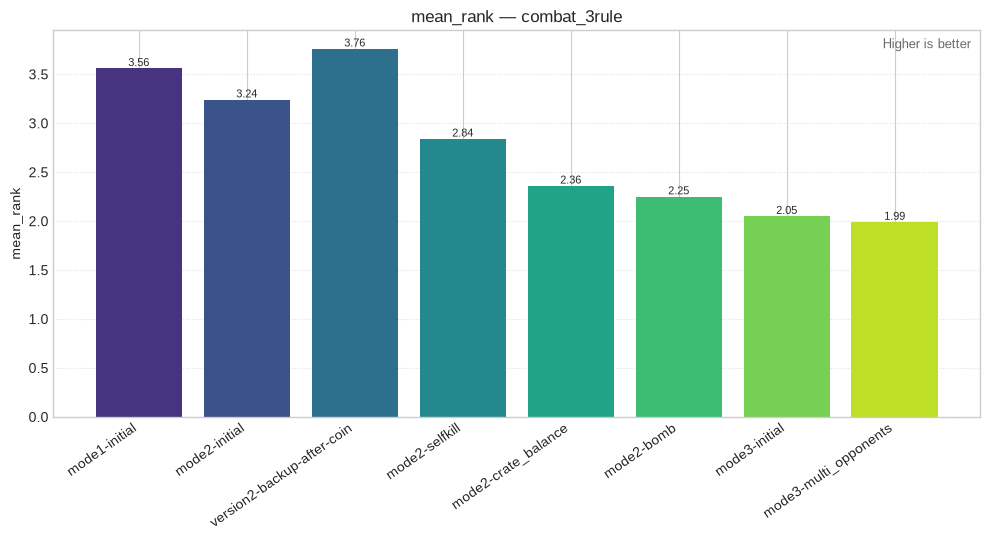

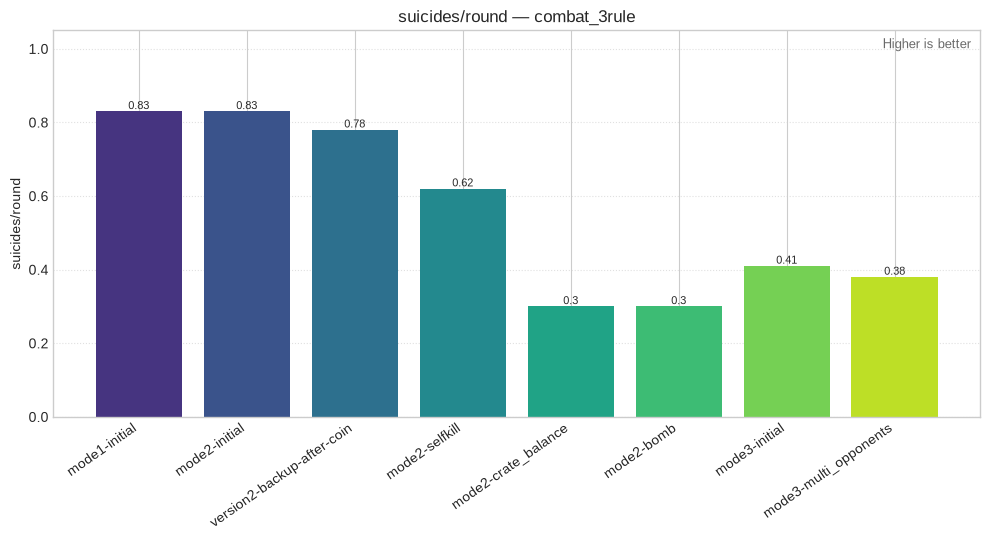

In [13]:
test_run = 'combat_3rule'
metric = 'mean_rank'
plot_metric(test_run, metric)
test_run = 'combat_3rule'
metric = 'suicides/round'
plot_metric(test_run, metric)

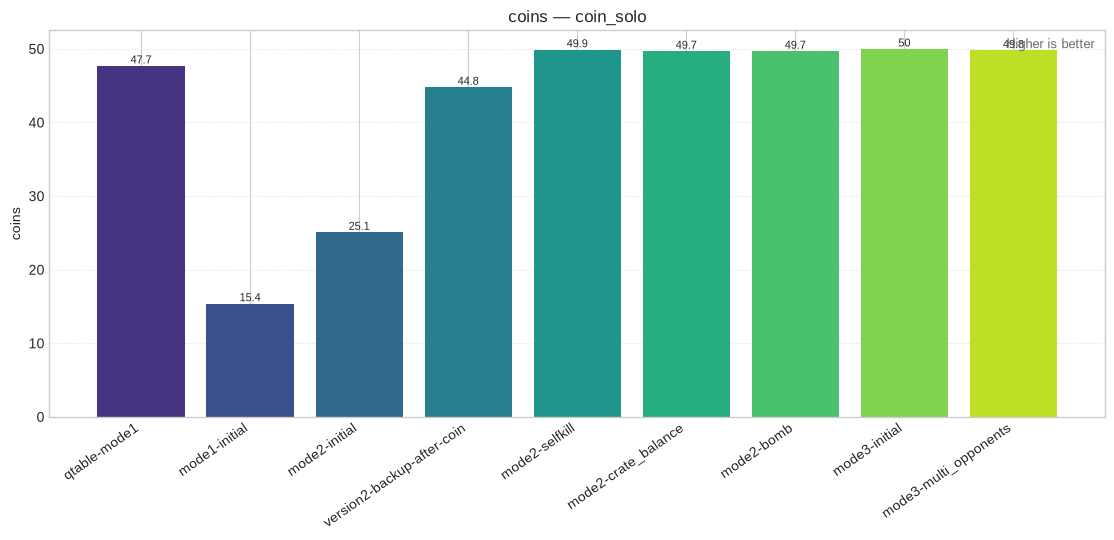

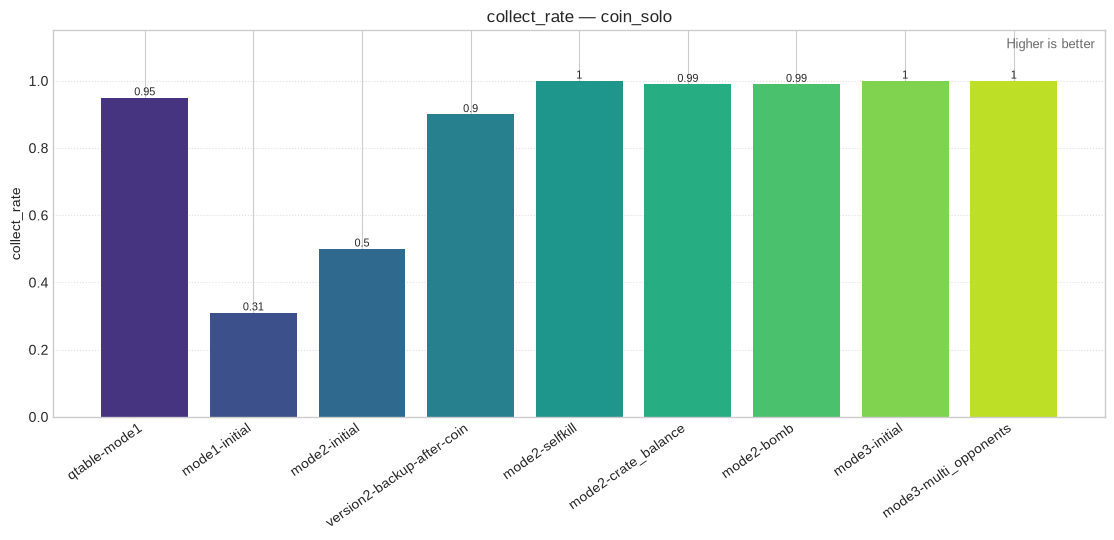

In [11]:
test_run = 'coin_solo'
metric = 'coins'
plot_metric(test_run, metric)

test_run = 'coin_solo'
metric = 'collect_rate'
plot_metric(test_run, metric)